In [1]:
import sys

import matplotlib.pyplot as plt

sys.path.append('../..')
from envs import Gambler
from models.value_based import value_iteration

%matplotlib inline

**Acknowledgement** This problem comes from *Reinforcement Learning and Introduction* written by Sutton and Barto.

**Gambler’s Problem** A gambler has the opportunity to make bets on the outcomes of a sequence of coin flips. If the coin comes up heads, he wins as many dollars as he has staked on that flip; if it is tails, he loses his stake. The game ends when the gambler wins by reaching his goal of 100 dollars, or loses by running out of money. On each flip, the gambler must decide what portion of his capital to stake, in integer numbers of dollars. This problem can be formulated as an undiscounted, episodic, finite MDP. The state is the gambler’s capital, $s \in \{1, 2,\ldots, 99\}$ and the actions are stakes, $a \in \{0, 1, \ldots, \min(s, 100 - s)\}$. The reward is zero on all transitions except those on which the gambler reaches his goal, when it is +1.

In [2]:
env = Gambler(0.4)
_ = env.reset()

**Value iteration** optimizes policy only after evaluating policy one sweep, since the policy evaluation step of policy iteration can be truncated in several ways without losing the convergence guarantees of policy iteration.

$$ v_{k+1}(s) \overset{\cdot}{=} \max_a \sum_{s', r} p(s',r|s,a)[r+\gamma v_k(s')]$$

$$\pi(s)= \mathop{\arg\max}_a \sum_{s', r} p(s',r|s,a)[r+\gamma v_k(s')]$$

In [3]:
v, pi, v_hist = value_iteration(env, eps=1e-5, verbose=1)

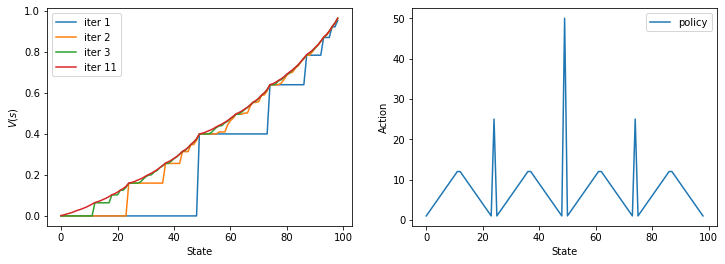

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(v_hist[0][1:-1], label='iter 1')
ax[0].plot(v_hist[1][1:-1], label='iter 2')
ax[0].plot(v_hist[2][1:-1], label='iter 3')
ax[0].plot(v_hist[-1][1:-1], label='iter %d' % len(v_hist))
ax[0].set_xlabel('State')
ax[0].set_ylabel('$V(s)$')
ax[0].legend()
ax[1].plot(pi[1:-1], label='policy')
ax[1].set_xlabel('State')
ax[1].set_ylabel('Action')
ax[1].legend()
plt.show()